In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import gapMetrics
import bacteriaSys
import controllers
random.seed(1)  # For reproducibility
np.random.seed(1)

In [3]:
#Function from data to bpc
# Assumed P controller with gain K
def data_to_bpc(u,x,K):
    A_hat, B_hat = gapMetrics.estimate_AB(u.T, x.T)
    C = np.array([[0, 1]])
    D = np.array([[0]])
    num, den = gapMetrics.ss_to_tf_discrete(A_hat, B_hat, C, D)
    Abk = A_hat - B_hat * K
    num3, den3 = gapMetrics.ss_to_tf_discrete(Abk, B_hat, C, D)
    bpc, _, _ = gapMetrics.vgap_bpc(num, den, num3, den3)
    return bpc

#
def data_to_vgap(u1, x1, u2, x2):
    A_hat1, B_hat1 = gapMetrics.estimate_AB(u1.T, x1.T)
    A_hat2, B_hat2 = gapMetrics.estimate_AB(u2.T, x2.T)
    C = np.array([[0, 1]])
    D = np.array([[0]])
    num1, den1 = gapMetrics.ss_to_tf_discrete(A_hat1, B_hat1, C, D)
    num2, den2 = gapMetrics.ss_to_tf_discrete(A_hat2, B_hat2, C, D)
    v_gap, _ = gapMetrics.vgap_metric(num1, den1, num2, den2)
    return v_gap

def direct_vgap(A1, B1, C1, D1, A2, B2, C2, D2):
    num1, den1 = gapMetrics.ss_to_tf_discrete(A1, B1, C1, D1)
    num2, den2 = gapMetrics.ss_to_tf_discrete(A2, B2, C2, D2)
    v_gap, _ = gapMetrics.vgap_metric(num1, den1, num2, den2)
    return v_gap

In [4]:
#LQR wrapper

def LQR_wrapper(u,x):
    Q = np.eye(2)
    # Q[1, 1] = 1
    R = np.eye(1) #TODO: can adapt to n change
    T_d = 20  #data length for LQR
    U0 = u[0:T_d].T        # shape (m, T)  == U_{0,1,T}
    X0 = x[0:T_d, :].T # shape (n, T)  == X_{0,T}
    X1 = x[1:T_d+1, :].T # shape (n, T)  == X_{1,T}
    K_control = controllers.DataLQRcontroller(U0, X0, X1, Q, R)
    return K_control

In [7]:
#define parameters
num_systems = 100
T = 50 #number of data points each system
L = 10  #Hankel matrix depth; 15 before
p = 2 #output dimension
# p = 1 #output dimension
m = 1 #input dimension
# C = np.array([[0.5, 1]])
C = np.eye(p)
D = np.zeros((p, m))
u = gapMetrics.persistently_exciting_input(T, m=1, std=1.0)
stored_hankels = []
H_u = gapMetrics.hankel_matrix(u, L)
#Check rank of H_u
rank_H_u = np.linalg.matrix_rank(H_u)
if rank_H_u < L:
    print(f"Warning: Hankel matrix of input has rank {rank_H_u} which is less than L={L}.")
else:
    print(f"Hankel matrix of input has full rank {rank_H_u}.")

Hankel matrix of input has full rank 10.


In [ ]:
#Do not run when reusing the 100 fixed output
stored_x = []
stored_y = []
#store A and B for checking
stored_A = []
stored_B = []
random.seed(1) #for reproducibility
for i in range(num_systems):
    # random_params_1 = random.random()
    # random_params_2 = random.random()
    params_1 = bacteriaSys.random_parameters_2()
    random_params_1 = params_1["deltam"]
    # print("deltam:", random_params_1)
    random_params_2 = params_1["deltaM"]
    # print("deltaM:", random_params_2)
    # print("Generating system", i+1, "with params:", random_params_1, random_params_2)
    A, B =bacteriaSys.discretize_AB(random_params_1, random_params_2, 1.0)
    # A, B, C, D = gapMetrics.random_discrete_system_stable(n=2, m=1, p=1)
    # A, B, _, _ = random_discrete_system_stable(n=2, m=1, p=1, rho_target=0.5)
    # print("A matrix:\n", A)
    # print("B matrix:\n", B)
    x, y = gapMetrics.simulate_system(A, B, C, D, u)
    # print("y shape:", y.shape)
    H_y = gapMetrics.hankel_matrix(y, L)
    # print("H_y shape:", H_y.shape)
    H = np.vstack([H_u, H_y])
    stored_x.append(x)
    stored_y.append(y)
    stored_hankels.append(H)
    stored_A.append(A)
    stored_B.append(B)

In [ ]:
#Do not run if you are generating new random systems, only if you are reusing the 100 fixed output
data = np.load("systems_data.npz", allow_pickle=True)

stored_x = data["stored_x"]
stored_y = data["stored_y"]
stored_hankels = data["stored_hankels"]
stored_A = data["stored_A"]
stored_B = data["stored_B"]
u = data["u"]

np.savez(
    "systems_data.npz",
    stored_x=stored_x,
    stored_y=stored_y,
    stored_hankels=stored_hankels,
    stored_A=stored_A,
    stored_B=stored_B,
    u=u
)

In [9]:
#compute L gaps
m = 1      # number of inputs
n = 2      # state dimension
D_l = np.zeros((num_systems, num_systems))
for i in range(num_systems):
    for j in range(i+1, num_systems):
        gij, *_ = gapMetrics.Lgap_metric(stored_hankels[i], stored_hankels[j], m, n, L, use_alt_formula=False)
        D_l[i, j] = gij
        D_l[j, i] = gij

# #compute v-gaps from data
# D_v = np.zeros((num_systems, num_systems))
# for i in range(num_systems):
#     for j in range(i+1, num_systems):
#         vij = data_to_vgap(u, stored_x[i], u, stored_x[j])
#         D_v[i, j] = vij
#         D_v[j, i] = vij
#         # print("v-gap between system", i, "and", j, ":", vij)
# #problem: takes too long

# #compute v-gaps
# D_v = np.zeros((num_systems, num_systems))
# for i in range(num_systems):
#     for j in range(i+1, num_systems):
#         vij = direct_vgap(stored_A[i], stored_B[i], C, D, stored_A[j], stored_B[j], C, D)
#         D_v[i, j] = vij
#         D_v[j, i] = vij
#         # print("v-gap between system", i, "and", j, ":", vij)
# #problem: takes too long

# # print("D_l:", D_l)

# #get their difference
# D_d = D_l - D_v


In [ ]:
#For latex
import csv

with open("gap_metrics_heat.csv", "w", newline="") as f:
    writer = csv.writer(f)
    
    # header
    # writer.writerow(["i", "j", "D_l", "D_v", "D_d"])
    writer.writerow(["i", "j", "D_l"])
    
    for i in range(num_systems):
        for j in range(num_systems):
            Dl = D_l[i, j]
            # Dv = D_v[i, j]
            # Dd = D_d[i, j]
            
            # writer.writerow([i, j, Dl, Dv, Dd])
            writer.writerow([i, j, Dl])

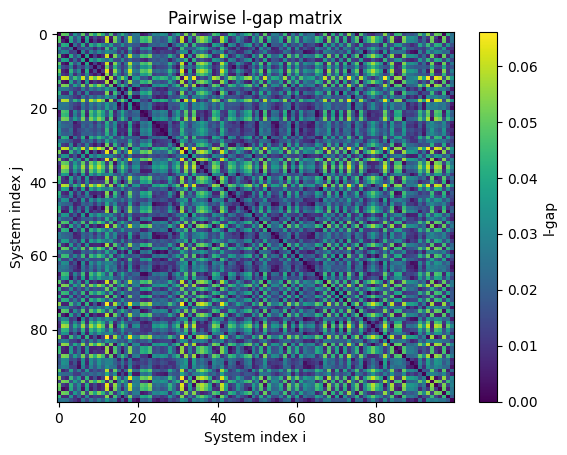

In [11]:
plt.figure()
plt.imshow(D_l, interpolation="nearest", aspect="auto")
plt.colorbar(label="l-gap")
plt.title("Pairwise l-gap matrix")
plt.xlabel("System index i")
plt.ylabel("System index j")
plt.savefig("heatmapL.png",dpi=300)
plt.show()
# fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# im1 = axes[0].imshow(D_l, interpolation="nearest", aspect="auto")
# axes[0].set_title("L-Gap")
# axes[0].set_xlabel("System index i")
# axes[0].set_ylabel("System index j")
# fig.colorbar(im1, ax=axes[0])

# im2 = axes[1].imshow(D_v, interpolation="nearest", aspect="auto")
# axes[1].set_title("v-Gap")
# axes[1].set_xlabel("System index i")
# axes[1].set_ylabel("System index j")
# fig.colorbar(im2, ax=axes[1])

# im3 = axes[2].imshow(D_d, interpolation="nearest", aspect="auto")
# axes[2].set_title("Difference (L-Gap - v-Gap)")
# axes[2].set_xlabel("System index i")
# axes[2].set_ylabel("System index j")
# fig.colorbar(im3, ax=axes[2])

# plt.tight_layout()
# plt.show()

# #TODO: max diff vs. T (or not important?)

In [14]:
#For performance degradation bound
#assumed ||W|| = 1. Currently the case with eye for Q and R

# x: shape (51, 2)
# u: shape (50, 1)

def performance_degradation_bound(i, j, D_l, x_all, u_all, N):
    #i is the one with the controller, j is the one we apply it to
    epsilon = D_l[i, j]
    x = x_all[i] # shape (51, 2)
    u = u_all # shape (50, 1)
    x = x[:L] # shape (L, 2)
    u = u[:L] # shape (L, 1)
    w = np.concatenate([
        x.reshape(-1, 1),
        u.reshape(-1, 1)
    ], axis=0)
    value = (2*epsilon + epsilon**2) * np.linalg.norm(w, 2)
    return value

test_bound = performance_degradation_bound(0, 1, D_l, stored_x, u, L)
print("Performance degradation", test_bound)

Performance degradation 0.7029444465155495


In [10]:
def Gap_margin_from_K(K, C, y, H_system, L):
    K_prep = K @ np.linalg.pinv(C)     # shape (m, p)

    #test if y is just random
    # y = np.random.randn(*y.shape)  # shape (T, p)

    u_ctrl = np.array([(K_prep @ y[i]).ravel() for i in range(y.shape[0])])
    #check data
    # print("y[1]:", (K_prep @ y[1].reshape(-1, 1)).ravel())
    # print("u_ctrl[1]:", u_ctrl[1])

    H_y_L = gapMetrics.hankel_matrix(y, L)
    H_u_L = gapMetrics.hankel_matrix(u_ctrl, L)

    H_C_prep = np.vstack([H_y_L, H_u_L])   # if graph convention is [y;u]

    gap_val, _, _, _ = gapMetrics.Lgap_metric(H_system, H_C_prep, m, n, L, use_alt_formula=False)
    margin = 1.0 - gap_val

    return {"gap_to_Cperp": gap_val, "margin": margin}

# for i in range(num_systems):
#     print("System", i)
#     K = LQR_wrapper(u, stored_x[i])
#     Hux = stored_hankels[i]
#     result = Gap_margin_from_K(K, C, stored_x[i], Hux, L)
    # print("Gap to C perp:", result["gap_to_Cperp"])
    # print("Margin:", result["margin"])

K = LQR_wrapper(u, stored_x[1])
Hux = stored_hankels[1]
result = Gap_margin_from_K(K, C, stored_x[1], Hux, L)
print("Gap to C perp:", result["gap_to_Cperp"])
print("Margin:", result["margin"])

Gap to C perp: 0.9741763860004902
Margin: 0.02582361399950983


In [11]:
#best working method so far
def farthest_seeds(D, m, mode="min"):
    """
    pick m plants far apart.
    mode:
      - "avg": next seed maximizes average distance to existing plants
      - "min": next seed maximizes minimum distance to existing plants
    """
    N = D.shape[0]
    if m > N:
        raise ValueError("m cannot exceed number of plants")

    # First two: farthest pair
    i0, j0 = np.unravel_index(np.argmax(D), D.shape)
    seeds = [int(i0), int(j0)]

    while len(seeds) < m:
        candidates = [i for i in range(N) if i not in seeds]
        if mode == "avg":
            scores = [float(np.mean(D[i, seeds])) for i in candidates]
        elif mode == "min":
            scores = [float(np.min(D[i, seeds])) for i in candidates]
        else:
            raise ValueError("mode must be 'avg' or 'min'")
        seeds.append(int(candidates[int(np.argmax(scores))]))

    return seeds


def assign_by_smallest_group_average(D, seeds, order="hard_first"):
    """
    Incrementally assign remaining points.
    Each point is assigned to the group that yields smallest average distance to current members.
    """
    N = D.shape[0]
    groups = {s: [s] for s in seeds}  # key=seed id, value=list of members

    remaining = [i for i in range(N) if i not in seeds]

    if order == "hard_first":
        # points farthest from the seed set get assigned first
        seed_arr = np.array(seeds, dtype=int)
        d_to_seedset = np.min(D[:, seed_arr], axis=1)
        remaining.sort(key=lambda i: -d_to_seedset[i])
    elif order == "index":
        pass
    else:
        raise ValueError("order must be 'hard_first' or 'index'")

    for i in remaining:
        best_seed = None
        best_cost = np.inf
        for s, members in groups.items():
            cost = float(np.mean(D[i, members]))  # average distance to group members
            if cost < best_cost:
                best_cost = cost
                best_seed = s
        groups[best_seed].append(int(i))

    return groups  # dict(seed -> members)


def medoid_of_group(D, members):
    """
    Helper: choose leader as medoid (min sum distance within group).
    """
    members = np.array(members, dtype=int)
    subD = D[np.ix_(members, members)]
    k = int(np.argmin(subD.sum(axis=1)))
    return int(members[k])


def build_groups_and_check_thresholds(D, groups_dict):
    """
    Find leader, compute threshold, verify all within threshold.
    threshold_fn(members, leader) -> eps
      If None, eps is treated as +inf (no check).
    try_repair_leader:
      If True, and chosen medoid fails, try any member as leader that passes the threshold.
    """
    out = []
    well_pose = 1
    for seed, members in groups_dict.items():
        leader = medoid_of_group(D, members)
         
        K = LQR_wrapper(u, stored_x[leader])
        # print("K for leader", leader, ":", K)
        # print("stored_x[leader]:", u.shape)
        # eps = data_to_bpc(u, stored_x[leader], K)
        eps = Gap_margin_from_K(K, C, stored_x[leader], stored_hankels[leader], L)["margin"]
        # print("Threshold for leader", leader, ":", eps)
        dists = D[np.array(members, dtype=int), leader]

        ok = np.all(dists <= eps + 1e-12)

        # if (not ok) and try_repair_leader and threshold_fn is not None:
        #     # try to find any member that makes the group feasible
        #     repaired = False
        #     for cand in members:
        #         eps_c = float(threshold_fn(members, cand))
        #         if np.all(D[np.array(members, dtype=int), cand] <= eps_c + 1e-12):
        #             leader = int(cand)
        #             eps = eps_c
        #             repaired = True
        #             break
        #     ok = repaired

        if not ok:
            # provide a helpful error message
            # worst = float(np.max(dists))
            # raise ValueError(
            #     f"Threshold violation for group seeded by {seed}: "
            #     f"leader={leader}, eps={eps:.4g}, worst_dist={worst:.4g}, size={len(members)}"
            # )
            well_pose = 0

        out.append({"seed": int(seed), "leader": int(leader), "eps": float(eps), "members": [int(x) for x in members]})

    return out, well_pose


# ----- Full pipeline -----

def cluster_farthest_assign_medoid_threshold(D, m, seed_mode="min",
                                            assign_order="hard_first"):
    """
    Implements 3 steps:
      1) farthest m plants
      2) one-by-one assignment to smallest average distance group
      3) leader = medoid, check all within leader threshold
    """
    seeds = farthest_seeds(D, m, mode=seed_mode)
    groups_dict = assign_by_smallest_group_average(D, seeds, order=assign_order)
    groups = build_groups_and_check_thresholds(D, groups_dict)
    return groups


In [12]:
#automatically find m by checking eps
def clustering_with_auto_m(D, eps, seed_mode="avg", assign_order="hard_first"):
    N = D.shape[0]
    for m in range(1, N+1):
        try:
            print(f"Trying m={m} clusters...")
            groups = cluster_farthest_assign_medoid_threshold(D, m, seed_mode, assign_order)
            check_out = 0
            for g in groups:
                leader = g["leader"]
                members = g["members"]
                condition = all(D[leader, m] < eps for m in members)
                print("leader:", leader, "valid:", condition)
                if not condition:
                    check_out = 1
            if check_out == 0:
                print(f"Successfully clustered with m={m} clusters, eps={eps:.4f}")
                return groups
            elif m == N:
                print(f"All systems in one group with m={m}, eps={groups[0]['eps']:.4f}")
                return groups
        except ValueError as e:
            print(f"Failed with m={m} clusters: {e}")
    raise ValueError("Failed to cluster within threshold for any m.")

In [13]:
# eps = 0.02
# groups = leader_groups(D, eps)
# groups = leader_groups2(D)
# groups = leader_groups_fixed(D, 3)
# groups, well_pose = cluster_farthest_assign_medoid_threshold(D_l, 5)
# print("well_pose:", well_pose)
# groups = clustering_with_auto_m(D_l, eps)
for m in range(1, num_systems+1):
    print(f"Trying m={m} clusters...")
    groups, well_pose = cluster_farthest_assign_medoid_threshold(D_l, m, seed_mode="avg", assign_order="hard_first")
    if well_pose == 1:
        print(f"Successfully clustered with m={m} clusters.")
        break
for g in groups:
    print("leader:", g["leader"], "size:", len(g["members"]), "members:", g["members"])
# print("groups:", groups)
# groups = [{"leader": c, "members": [...]}, ...]

N = D_l.shape[0]
leader_of = np.full(N, -1, dtype=int)
dist_to_leader = np.zeros(N)

for g in groups:
    leader = g["leader"]
    for i in g["members"]:
        leader_of[i] = leader
        dist_to_leader[i] = D_l[leader, i]

Trying m=1 clusters...
Successfully clustered with m=1 clusters.
leader: 58 size: 26 members: [12, 80, 22, 36, 70, 65, 0, 75, 78, 97, 60, 21, 51, 68, 58, 37, 41, 35, 79, 23, 94, 14, 84, 87, 31, 18]
leader: 50 size: 74 members: [93, 74, 90, 19, 15, 83, 5, 17, 77, 99, 63, 45, 20, 62, 89, 88, 81, 92, 38, 64, 29, 55, 25, 59, 33, 66, 46, 42, 49, 27, 54, 50, 24, 56, 3, 7, 26, 53, 28, 4, 61, 69, 72, 44, 91, 9, 40, 30, 98, 16, 71, 47, 11, 43, 48, 86, 85, 1, 96, 57, 13, 76, 6, 39, 2, 32, 8, 67, 73, 52, 10, 95, 82, 34]


In [ ]:
# import csv

with open("cluster_assignments.csv", "w", newline="") as f:
    writer = csv.writer(f)
    
    # header
    writer.writerow(["index", "leader", "dist_to_leader"])
    
    for i in range(N):
        writer.writerow([i, leader_of[i], dist_to_leader[i]])

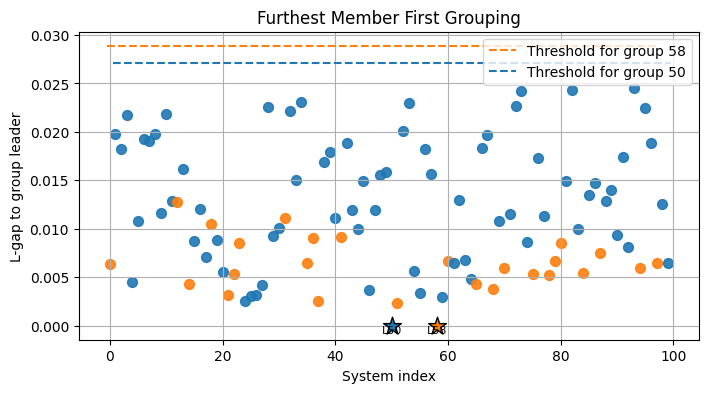

In [14]:
plt.figure(figsize=(8, 4))

unique_leaders = sorted(set(leader_of))
colors = plt.cm.tab10(range(len(unique_leaders)))
leader_color = {l: colors[k] for k, l in enumerate(unique_leaders)}

for i in range(N):
    l = leader_of[i]
    if i == l:
        # leader: star marker
        plt.scatter(
            i,
            dist_to_leader[i],
            marker="*",
            s=180,
            color=leader_color[l],
            edgecolor="k",
            zorder=3,
        )
        plt.text(i, 0, f"L{l}", ha="center", va="top", fontsize=8)
    else:
        plt.scatter(
            i,
            dist_to_leader[i],
            color=leader_color[l],
            s=50,
            alpha=0.9,
        )

for g in groups:
    leader = g["leader"]
    members = g["members"]
    eps = g["eps"]
    plt.hlines(
        eps,
        xmin=min(members) - 0.5,
        xmax=max(members) + 0.5,
        colors=leader_color[leader],
        linestyles="--", 
        label=f"Threshold for group {leader}"
    )

plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.xlabel("System index")
plt.ylabel("L-gap to group leader")
plt.title("Furthest Member First Grouping")
plt.grid(True)
plt.legend()
plt.show()


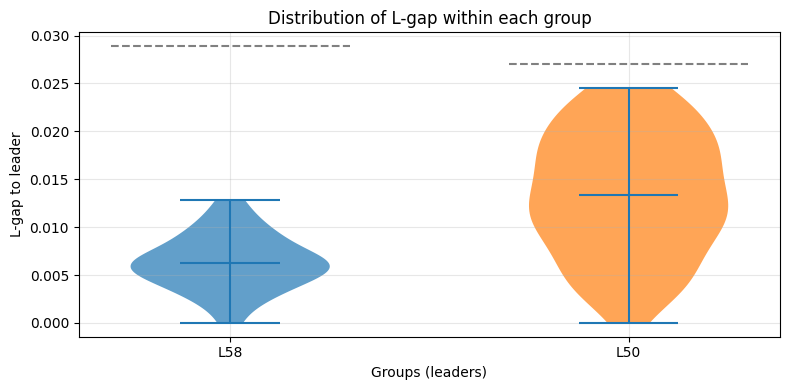

In [15]:
#violin plot for distribution of distances to leader within each group
group_data = []
labels = []

for g in groups:
    leader = g["leader"]
    members = g["members"]
    
    values = [dist_to_leader[i] for i in members]
    
    group_data.append(values)
    labels.append(f"L{leader}")

plt.figure(figsize=(8, 4))

vp = plt.violinplot(group_data, showmeans=True, showmedians=False)

# color each violin
unique_leaders = [g["leader"] for g in groups]
colors = plt.cm.tab10(range(len(unique_leaders)))

for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)

# # optional: color mean lines
# for part in ("cbars", "cmins", "cmaxes", "cmeans"):
#     if part in vp:
#         vp[part].set_color("black")

#plot threshold lines for each group
for i, g in enumerate(groups, start=1):
    plt.hlines(
        g["eps"],
        xmin=i - 0.3,
        xmax=i + 0.3,
        colors="gray",
        linestyles="--",
        linewidth=1.5
    )

# for i, values in enumerate(group_data, start=1):
#     x = np.random.normal(i, 0.05, size=len(values))  # jitter
#     plt.scatter(x, values, color="black", s=15, alpha=0.6)

plt.xticks(range(1, len(labels) + 1), labels)
plt.xlabel("Groups (leaders)")
plt.ylabel("L-gap to leader")
plt.title("Distribution of L-gap within each group")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
#proof of controllability (new)
def control_effectiveness(A, B, K, init=np.array([2,2]), goal=np.array([0,0]), N=50):
    """
    N is the number of steps to simulate.
    """
    x = init.copy()
    total_error = 0.0
    Q = np.eye(2)
    R = np.eye(1) #TODO: can adapt to n change
    for _ in range(N):
        u = -K @ (x - goal)
        x = A @ x + B @ u
        # total_error += np.linalg.norm(x - goal) + np.linalg.norm(u)
        # total_error += np.linalg.norm(x - goal)
        e = x - goal
        total_error += e.T @ Q @ e + u.T @ R @ u
    return total_error
    
error = {}

for g in groups:
    print("leader:", g["leader"], "size:", len(g["members"]), "members:", g["members"])
    K_leader = LQR_wrapper(u, stored_x[g["leader"]])
    #calculate leader error
    A_leader = stored_A[g["leader"]]
    B_leader = stored_B[g["leader"]]
    # A_cl_leader = A_leader - B_leader @ K_leader
    # eigs_leader = np.linalg.eigvals(A_cl_leader)
    # print(f"Leader system {g['leader']} eigs: {eigs_leader}")
    leader_error = control_effectiveness(A_leader, B_leader, K_leader)
    error[g["leader"]] = leader_error
    #calculate member error
    for m in g["members"]:
        A = stored_A[m]
        B = stored_B[m]
        # A_cl = A - B @ K_leader
        # eigs = np.linalg.eigvals(A_cl)
        # print(f"System {m} eigs: {eigs}")
        member_error = control_effectiveness(A, B, K_leader)
        error[m] = member_error

#plot errors
# plt.figure(figsize=(8, 4))
# for g in groups:
#     leader = g["leader"]
#     members = g["members"]
#     plt.scatter(
#         members,
#         [error[m] for m in members],
#         color=leader_color[leader],
#         s=50,
#         alpha=0.9,
#         label=f"Group led by {leader}"
#     )
# plt.grid(True)
# plt.xlabel("System index")
# plt.ylabel("Error to reach goal")
# plt.title("Error under Leader's Controller")   

leader: 58 size: 26 members: [12, 80, 22, 36, 70, 65, 0, 75, 78, 97, 60, 21, 51, 68, 58, 37, 41, 35, 79, 23, 94, 14, 84, 87, 31, 18]
leader: 50 size: 74 members: [93, 74, 90, 19, 15, 83, 5, 17, 77, 99, 63, 45, 20, 62, 89, 88, 81, 92, 38, 64, 29, 55, 25, 59, 33, 66, 46, 42, 49, 27, 54, 50, 24, 56, 3, 7, 26, 53, 28, 4, 61, 69, 72, 44, 91, 9, 40, 30, 98, 16, 71, 47, 11, 43, 48, 86, 85, 1, 96, 57, 13, 76, 6, 39, 2, 32, 8, 67, 73, 52, 10, 95, 82, 34]


In [26]:
#All optimal example
error_optimal = {}
for i in range(num_systems):
    A = stored_A[i]
    B = stored_B[i]
    K = LQR_wrapper(u, stored_x[i])
    error_o = control_effectiveness(A, B, K)
    error_optimal[i] = error_o

# plt.figure(figsize=(8, 4))
# for g in groups:
#     leader = g["leader"]
#     members = g["members"]
#     plt.scatter(
#         members,
#         [error_optimal[m] for m in members],
#         color=leader_color[leader],
#         s=50,
#         alpha=0.9,
#     )
# plt.grid(True)
# plt.xlabel("System index")
# plt.ylabel("Error to reach goal")
# plt.title("Error of Controllers (All Optimal)")
# plt.legend()

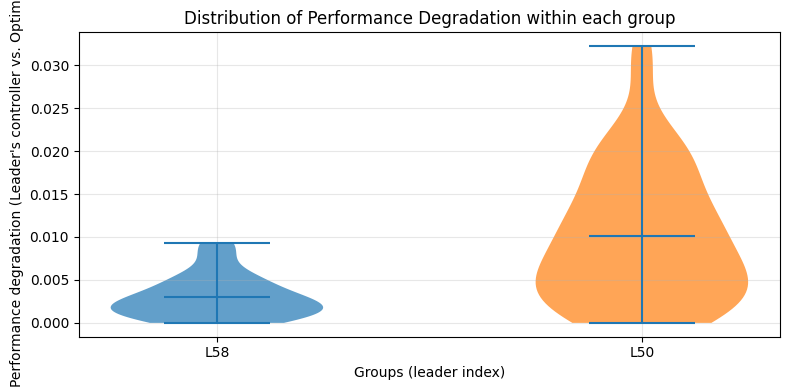

In [27]:
delta_error = {i: error[i] - error_optimal[i] for i in range(num_systems)}

#violin plot
group_data_error = []
labels_error = []

for g in groups:
    leader = g["leader"]
    members = g["members"]
    
    values = [delta_error[i] for i in members]
    
    group_data_error.append(values)
    labels_error.append(f"L{leader}")

plt.figure(figsize=(8, 4))

vp = plt.violinplot(group_data_error, showmeans=True, showmedians=False)

# color each violin
unique_leaders = [g["leader"] for g in groups]
colors = plt.cm.tab10(range(len(unique_leaders)))

for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)

# for i, values in enumerate(group_data, start=1):
#     x = np.random.normal(i, 0.05, size=len(values))  # jitter
#     plt.scatter(x, values, color="black", s=15, alpha=0.6)

plt.xticks(range(1, len(labels_error) + 1), labels_error)
plt.xlabel("Groups (leader index)")
plt.ylabel("Performance degradation (Leader's controller vs. Optimal)")
plt.title("Distribution of Performance Degradation within each group")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# import csv
# print(error)
with open("cluster_control_error.csv", "w", newline="") as f:
    writer = csv.writer(f)
    # header
    writer.writerow(["index", "leader", "error", "error_optimal", "delta_error"])
    for i in range(N):
        writer.writerow([i, leader_of[i], error[i], error_optimal[i], delta_error[i]])

w shape: (50, 2)


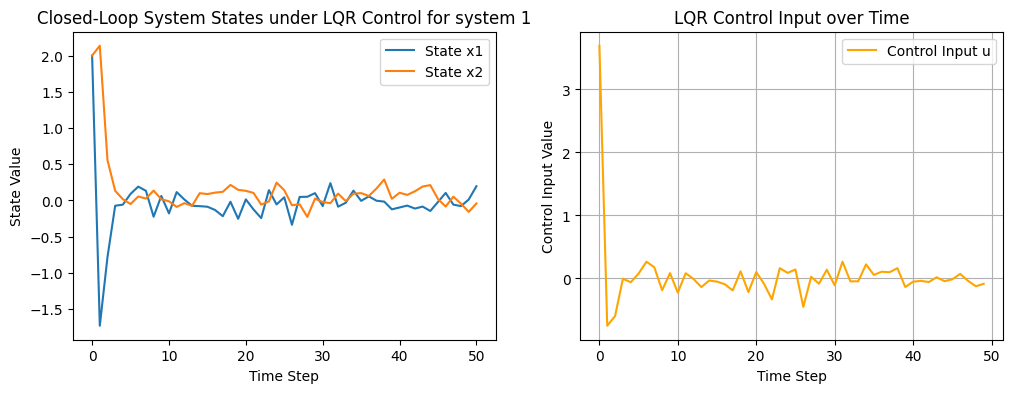

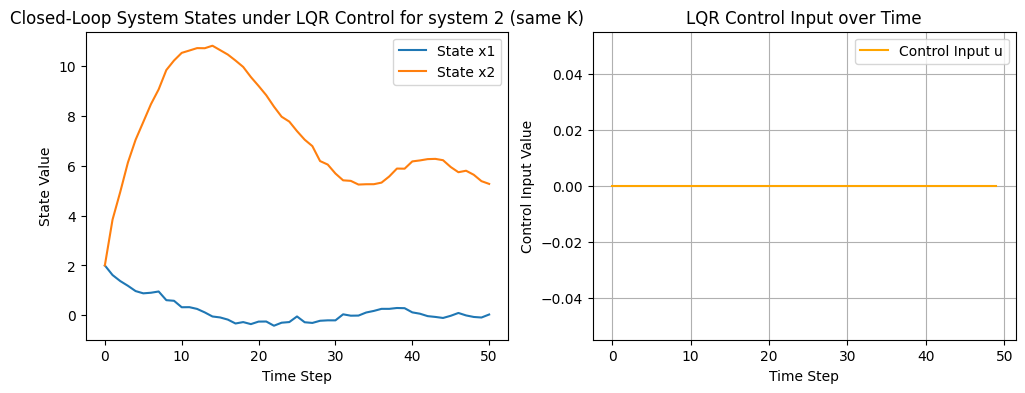

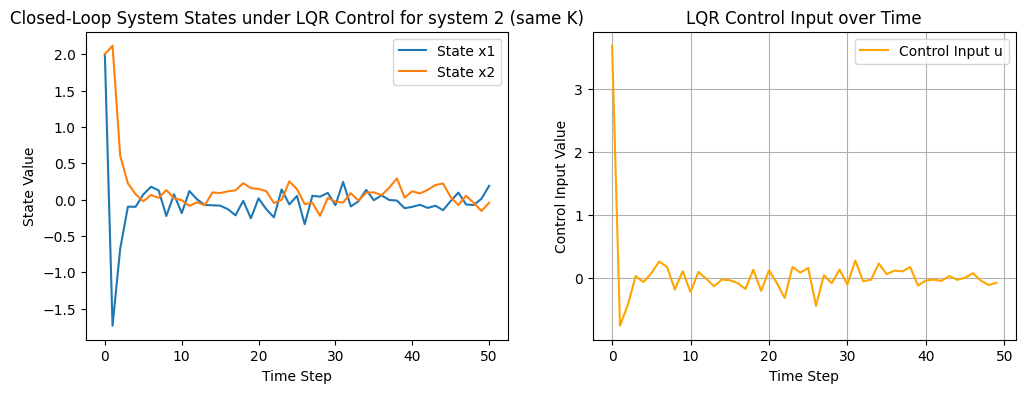

In [ ]:
#proof of controllability (old)

#test whether the same controller can be used for 2 systems
#LQR controller
Q = np.eye(2)
# Q[1,1] = 0 #get rid of x2 penalty
R = np.eye(1)*0.1
T_d = 20  #data length for LQR

U0 = u[0:T_d].T        # shape (m, T)  == U_{0,1,T}
X0 = stored_x[7][0:T_d, :].T # shape (n, T)  == X_{0,T}
X1 = stored_x[7][1:T_d+1, :].T # shape (n, T)  == X_{1,T}

# simulate closed loop system. Assumed using system 1 where A is a 2x2 matrix
N = 50 #number of control steps
#disturbance
w = np.random.randn(N, 2).reshape(-1, 2) * 0.1
print("w shape:", w.shape)

x0 = np.array([[2],[2]]) #initial state
x_cl = np.zeros((N+1, x0.shape[0], x0.shape[1]))
x_cl[0, :, :] = x0 #initial state
xf = np.array([[0],[0]]) #desired state
u_cl = np.zeros((N, R.shape[0], 1))
K_control = controllers.DataLQRcontroller(U0, X0, X1, Q, R)
# K_control = np.array([[2, 1]])  #test with wrong controller

for k in range(N):
    u_control = -K_control @ (x_cl[k] - xf) 
    # u_control = np.zeros((1, 1))
    #add disturbance
    x_cl[k+1] = stored_A[7] @ x_cl[k] + stored_B[7] @ u_control
    x_cl[k+1] += w[k].reshape(-1, 1)
    u_cl[k] = u_control

# Plot results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_cl[:,0,0], label='State x1')
plt.plot(x_cl[:,1,0], label='State x2')
plt.title('Closed-Loop System States under LQR Control for system 1')
plt.xlabel('Time Step')
plt.ylabel('State Value')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(N), -u_cl[:,0,0], label='Control Input u', color='orange')
plt.title('LQR Control Input over Time')
plt.xlabel('Time Step')
plt.ylabel('Control Input Value')
plt.legend()
plt.grid()
plt.show()

#system 2
for k in range(N):
    # u_control = -K_control @ (x_cl[k] - xf)
    u_control = np.zeros((1, 1))
    x_cl[k+1] = stored_A[1] @ x_cl[k] + stored_B[1] @ u_control + w[k].reshape(-1, 1)
    u_cl[k] = u_control

# Plot results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_cl[:,0,0], label='State x1')
plt.plot(x_cl[:,1,0], label='State x2')
plt.title('Closed-Loop System States under LQR Control for system 2 (same K)')
plt.xlabel('Time Step')
plt.ylabel('State Value')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(N), -u_cl[:,0,0], label='Control Input u', color='orange')
plt.title('LQR Control Input over Time')
plt.xlabel('Time Step')
plt.ylabel('Control Input Value')
plt.legend()
plt.grid()
plt.show()

#use same controller on system 2
for k in range(N):
    u_control = -K_control @ (x_cl[k] - xf)
    x_cl[k+1] = stored_A[1] @ x_cl[k] + stored_B[1] @ u_control + w[k].reshape(-1, 1)
    u_cl[k] = u_control

# Plot results
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(x_cl[:,0,0], label='State x1')
plt.plot(x_cl[:,1,0], label='State x2')
plt.title('Closed-Loop System States under LQR Control for system 2 (same K)')
plt.xlabel('Time Step')
plt.ylabel('State Value')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(N), -u_cl[:,0,0], label='Control Input u', color='orange')
plt.title('LQR Control Input over Time')
plt.xlabel('Time Step')
plt.ylabel('Control Input Value')
plt.legend()
plt.grid()
plt.show()

Leader: 58
K_control shape: (1, 2)
K_control:
 [[1.22425592 0.6264    ]]
number of members in group: 26


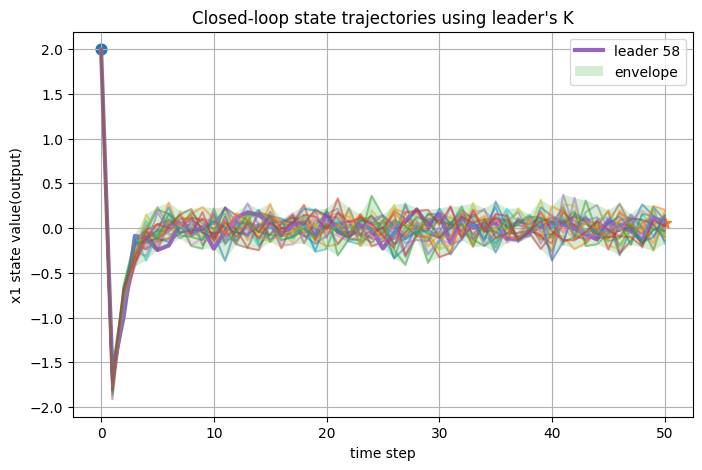

In [ ]:
# ----- choose one group only -----
g = groups[0]                 # or any specific group
leader = g["leader"]
members = g["members"]

# ----- LQR settings -----
Q = np.eye(2)
R = np.eye(1) * 0.1
T_d = 20
N = 50

x0 = np.array([[2.0], [2.0]])
xf = np.array([[0.0], [0.0]])

# ----- compute K only from the leader -----
U0 = u[0:T_d].T
X0 = stored_x[leader][0:T_d, :].T
X1 = stored_x[leader][1:T_d+1, :].T

K_control = controllers.DataLQRcontroller(U0, X0, X1, Q, R)
print("Leader:", leader)
print("K_control shape:", K_control.shape)
print("K_control:\n", K_control)
print("number of members in group:", len(members))

# ----- simulate all members with the same K -----
traj_dict = {}
u_dict = {}

for idx in members:
    # optional: same disturbance for all plants
    w = np.random.randn(N, 2) * 0.1

    x_cl = np.zeros((N + 1, x0.shape[0], x0.shape[1]))
    u_cl = np.zeros((N, R.shape[0], 1))
    x_cl[0] = x0

    A = stored_A[idx]
    B = stored_B[idx]

    for k in range(N):
        u_control = -K_control @ (x_cl[k] - xf)
        x_cl[k + 1] = A @ x_cl[k] + B @ u_control + w[k].reshape(-1, 1)
        u_cl[k] = u_control

    traj_dict[idx] = x_cl
    u_dict[idx] = u_cl

# ----- plot all state trajectories in one figure -----
t = np.arange(N + 1)

plt.figure(figsize=(8, 5))

# collect all x1 trajectories
x1_all = []

for idx in members:
    x_cl = traj_dict[idx]
    x1 = x_cl[:, 0, 0]
    x1_all.append(x1)

    if idx == leader:
        plt.plot(t, x1, linewidth=3, label=f"leader {idx}")
        plt.scatter(t[0], x1[0], s=60, marker="o")
        plt.scatter(t[-1], x1[-1], s=80, marker="*")
    else:
        plt.plot(t, x1, alpha=0.5, linewidth=1.5)

x1_all = np.array(x1_all)          # shape: (num_members, N+1)
lower = np.min(x1_all, axis=0)     # lower envelope
upper = np.max(x1_all, axis=0)     # upper envelope

plt.fill_between(t, lower, upper, alpha=0.2, label="envelope")

plt.xlabel("time step")
plt.ylabel("x1 state value(output)")
plt.title("Closed-loop state trajectories using leader's K")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# import csv

# put leader first, then the remaining members
ordered_members = [leader] + [idx for idx in members if idx != leader]

with open("group_trajectories.csv", "w", newline="") as f:
    writer = csv.writer(f)

    # header
    header = ["t", f"y1({leader})"]
    for k, idx in enumerate(ordered_members[1:], start=2):
        header.append(f"y{k}({idx})")
    writer.writerow(header)

    # rows
    for t in range(N + 1):
        row = [t]

        for idx in ordered_members:
            # first state component x_1
            y = traj_dict[idx][t, 0, 0]
            row.append(y)

        writer.writerow(row)

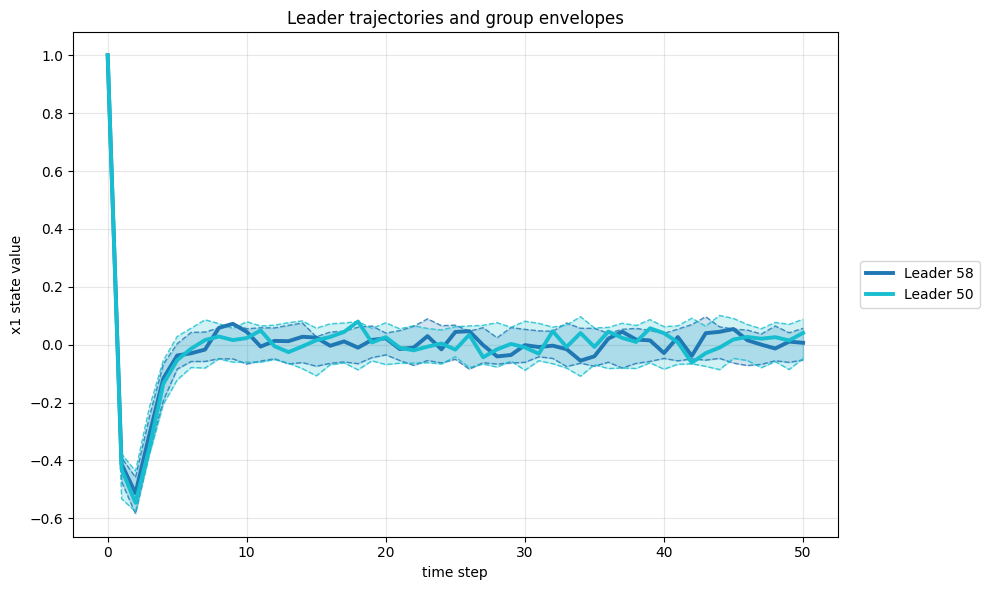

In [22]:
# ----- settings -----
Q = np.eye(2)
R = np.eye(1)
T_d = 20
N = 50

x0 = np.array([[1.0], [1.0]])
xf = np.array([[0.0], [0.0]])

# choose which state/output to plot
state_idx = 0   # 0 -> x1, 1 -> x2

t = np.arange(N + 1)

# store results for plotting + CSV
group_plot_data = []

# colormap
colors = plt.cm.tab10(np.linspace(0, 1, len(groups)))

# ----- simulate each group using its own leader controller -----
for group_id, g in enumerate(groups):
    leader = g["leader"]
    members = g["members"]

    # compute K from leader data
    U0 = u[0:T_d].T
    X0 = stored_x[leader][0:T_d, :].T
    X1 = stored_x[leader][1:T_d+1, :].T

    K_control = controllers.DataLQRcontroller(U0, X0, X1, Q, R)

    traj_dict = {}
    u_dict = {}

    for idx in members:
        # different disturbance for each system
        w = np.random.randn(N, 2) * 0.05

        x_cl = np.zeros((N + 1, x0.shape[0], x0.shape[1]))
        u_cl = np.zeros((N, R.shape[0], 1))
        x_cl[0] = x0

        A = stored_A[idx]
        B = stored_B[idx]

        for k in range(N):
            u_control = -K_control @ (x_cl[k] - xf)
            x_cl[k + 1] = A @ x_cl[k] + B @ u_control + w[k].reshape(-1, 1) * 0.5
            u_cl[k] = u_control

        traj_dict[idx] = x_cl
        u_dict[idx] = u_cl

    # collect the selected state for all members
    y_all = []
    for idx in members:
        y = traj_dict[idx][:, state_idx, 0]
        y_all.append(y)

    y_all = np.array(y_all)
    env_low = np.min(y_all, axis=0)
    env_high = np.max(y_all, axis=0)
    leader_y = traj_dict[leader][:, state_idx, 0]

    group_plot_data.append({
        "leader": leader,
        "members": members,
        "traj_dict": traj_dict,
        "u_dict": u_dict,
        "leader_y": leader_y,
        "env_low": env_low,
        "env_high": env_high,
        "color": colors[group_id],
    })

# ----- plot -----
plt.figure(figsize=(10, 6))

for data in group_plot_data:
    leader = data["leader"]
    members = data["members"]
    traj_dict = data["traj_dict"]
    c = data["color"]

    # # faint member trajectories
    # for idx in members:
    #     y = traj_dict[idx][:, state_idx, 0]
    #     if idx != leader:
    #         plt.plot(t, y, color=c, alpha=0.20, linewidth=1.2, zorder=1)

    # envelope
    plt.fill_between(
        t,
        data["env_low"],
        data["env_high"],
        color=c,
        alpha=0.20,
        zorder=2
    )

    # envelope boundaries
    plt.plot(t, data["env_low"], "--", color=c, linewidth=1.0, alpha=0.8, zorder=3)
    plt.plot(t, data["env_high"], "--", color=c, linewidth=1.0, alpha=0.8, zorder=3)

    # leader
    plt.plot(
        t,
        data["leader_y"],
        color=c,
        linewidth=2.8,
        label=f"Leader {leader}",
        zorder=4
    )

plt.xlabel("time step")
plt.ylabel(f"x{state_idx+1} state value")
plt.title("Leader trajectories and group envelopes")
plt.grid(True, alpha=0.3)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.tight_layout()
plt.show()

# ----- CSV export -----
# csv_filename = "group_leader_envelopes.csv"

# with open(csv_filename, "w", newline="") as f:
#     writer = csv.writer(f)

#     # header
#     header = ["t"]
#     for data in group_plot_data:
#         leader = data["leader"]
#         header.extend([
#             f"leader_{leader}",
#             f"env_low_{leader}",
#             f"env_high_{leader}",
#         ])
#     writer.writerow(header)

#     # rows
#     for k in range(N + 1):
#         row = [t[k]]
#         for data in group_plot_data:
#             row.extend([
#                 data["leader_y"][k],
#                 data["env_low"][k],
#                 data["env_high"][k],
#             ])
#         writer.writerow(row)

# print(f"CSV written to {csv_filename}")

well_pose: 1


IndexError: index 7 is out of bounds for axis 0 with size 7

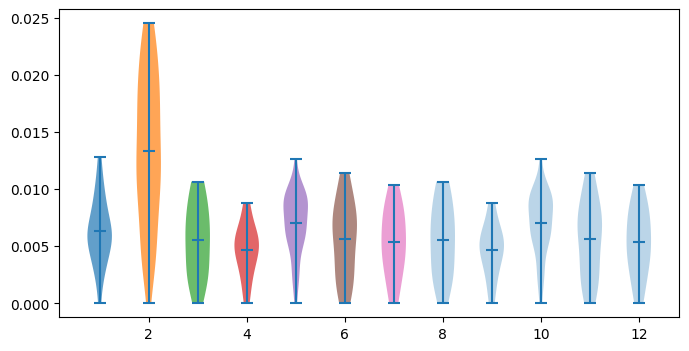

In [28]:
# eps = 0.02
# groups = leader_groups(D, eps)
# groups = leader_groups2(D)
# groups = leader_groups_fixed(D, 3)
groupsm, well_posem = cluster_farthest_assign_medoid_threshold(D_l, 5)
print("well_pose:", well_posem)

N = D_l.shape[0]
leader_of = np.full(N, -1, dtype=int)
dist_to_leader = np.zeros(N)

for g in groupsm:
    leader = g["leader"]
    for i in g["members"]:
        leader_of[i] = leader
        dist_to_leader[i] = D_l[leader, i]

#violin plot for distribution of distances to leader within each group
# group_datam = []
# labelsm = []

for g in groupsm:
    leader = g["leader"]
    members = g["members"]
    
    values = [dist_to_leader[i] for i in members]
    
    group_data.append(values)
    labels.append(f"L{leader}")

plt.figure(figsize=(8, 4))

vp = plt.violinplot(group_data, showmeans=True, showmedians=False)

# color each violin
# unique_leaders = []
for g in groupsm:
    unique_leaders.append(g["leader"])
colors = plt.cm.tab10(range(len(unique_leaders)))

for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)

# # optional: color mean lines
# for part in ("cbars", "cmins", "cmaxes", "cmeans"):
#     if part in vp:
#         vp[part].set_color("black")

#plot threshold lines for each group
for i, g in enumerate(groups, start=1):
    plt.hlines(
        g["eps"],
        xmin=i - 0.3,
        xmax=i + 0.3,
        colors="gray",
        linestyles="--",
        linewidth=1.5
    )

plt.vlines(
    len(groups) + 0.5,
    ymin=0,
    ymax=max(g["eps"] for g in groupsm) * 1.1,
    colors="black",
    linestyles="--",
    linewidth=2.0,
    # label="Furthest Member First Thresholds"
)

for i, g in enumerate(groupsm, start=len(groups)+1):
    plt.hlines(
        g["eps"],
        xmin=i - 0.3,
        xmax=i + 0.3,
        colors="gray",
        linestyles="--",
        linewidth=1.5
    )

# for i, values in enumerate(group_data, start=1):
#     x = np.random.normal(i, 0.05, size=len(values))  # jitter
#     plt.scatter(x, values, color="black", s=15, alpha=0.6)

plt.xticks(range(1, len(labels) + 1), labels)
plt.xlabel("Groups (leaders)")
plt.ylabel("L-gap to leader")
plt.title("Distribution of L-gap within each group")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

leader: 35 size: 15 members: [12, 23, 94, 80, 14, 87, 35, 60, 72, 37, 70, 78, 31, 51, 18]
leader: 52 size: 18 members: [93, 57, 85, 76, 6, 39, 2, 32, 8, 67, 73, 11, 52, 47, 10, 95, 82, 34]
leader: 90 size: 35 members: [74, 83, 45, 89, 81, 38, 29, 64, 66, 46, 42, 62, 49, 50, 56, 77, 33, 5, 54, 24, 3, 27, 55, 63, 90, 7, 25, 92, 59, 88, 99, 20, 19, 15, 17]
leader: 16 size: 18 members: [44, 69, 91, 61, 40, 48, 98, 1, 86, 96, 26, 16, 13, 71, 43, 4, 30, 9]
leader: 75 size: 14 members: [22, 36, 41, 79, 68, 84, 97, 53, 0, 28, 58, 75, 21, 65]


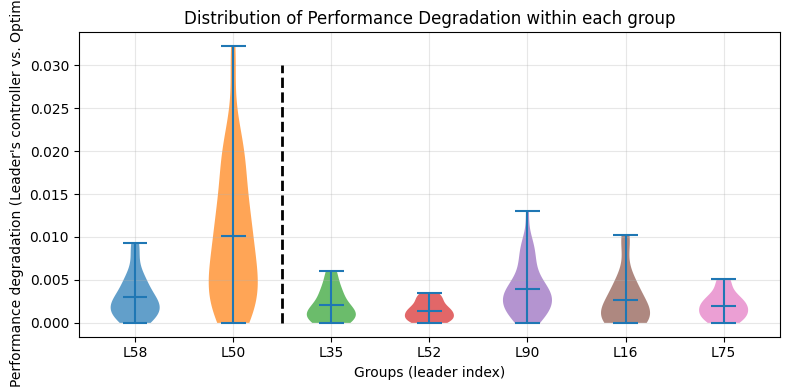

In [29]:
#proof of controllability (for adding 5)
    
error = {}

for g in groupsm:
    print("leader:", g["leader"], "size:", len(g["members"]), "members:", g["members"])
    K_leader = LQR_wrapper(u, stored_x[g["leader"]])
    #calculate leader error
    A_leader = stored_A[g["leader"]]
    B_leader = stored_B[g["leader"]]
    # A_cl_leader = A_leader - B_leader @ K_leader
    # eigs_leader = np.linalg.eigvals(A_cl_leader)
    # print(f"Leader system {g['leader']} eigs: {eigs_leader}")
    leader_error = control_effectiveness(A_leader, B_leader, K_leader)
    error[g["leader"]] = leader_error
    #calculate member error
    for m in g["members"]:
        A = stored_A[m]
        B = stored_B[m]
        # A_cl = A - B @ K_leader
        # eigs = np.linalg.eigvals(A_cl)
        # print(f"System {m} eigs: {eigs}")
        member_error = control_effectiveness(A, B, K_leader)
        error[m] = member_error

error_optimal = {}
for i in range(num_systems):
    A = stored_A[i]
    B = stored_B[i]
    K = LQR_wrapper(u, stored_x[i])
    error_o = control_effectiveness(A, B, K)
    error_optimal[i] = error_o

delta_errorm = {i: error[i] - error_optimal[i] for i in range(num_systems)}

#violin plot
# group_data_error = []
# labels_error = []

for g in groupsm:
    leader = g["leader"]
    members = g["members"]
    
    values = [delta_errorm[i] for i in members]
    
    group_data_error.append(values)
    labels_error.append(f"L{leader}")

plt.figure(figsize=(8, 4))

vp = plt.violinplot(group_data_error, showmeans=True, showmedians=False)

# color each violin
unique_leadersm = [g["leader"] for g in groupsm]
colors = plt.cm.tab10(range(len(unique_leadersm)+len(unique_leaders)))

for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)

# for i, values in enumerate(group_data, start=1):
#     x = np.random.normal(i, 0.05, size=len(values))  # jitter
#     plt.scatter(x, values, color="black", s=15, alpha=0.6)

plt.vlines(
    len(groups) + 0.5,
    ymin=0.0,
    ymax=0.03,
    colors="black",
    linestyles="--",
    linewidth=2.0,
    label="Furthest Member First Thresholds"
)

plt.xticks(range(1, len(labels_error) + 1), labels_error)
plt.xlabel("Groups (leader index)")
plt.ylabel("Performance degradation (Leader's controller vs. Optimal)")
plt.title("Distribution of Performance Degradation within each group")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
degree_error = {i: error[i] - error[leader_of[i]] for i in range(num_systems)}

#violin plot
group_data_error = []
labels_error = []

for g in groups:
    leader = g["leader"]
    members = g["members"]
    
    values = [degree_error[i] for i in members]
    
    group_data_error.append(values)
    labels_error.append(f"L{leader}")

plt.figure(figsize=(8, 4))

vp = plt.violinplot(group_data_error, showmeans=True, showmedians=False)

# color each violin
unique_leaders = [g["leader"] for g in groups]
colors = plt.cm.tab10(range(len(unique_leaders)))

for i, body in enumerate(vp["bodies"]):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)

# for i, values in enumerate(group_data, start=1):
#     x = np.random.normal(i, 0.05, size=len(values))  # jitter
#     plt.scatter(x, values, color="black", s=15, alpha=0.6)

plt.xticks(range(1, len(labels_error) + 1), labels_error)
plt.xlabel("Groups (leader index)")
plt.ylabel("Performance degradation (Leader's controller vs. Optimal)")
plt.title("Distribution of Performance Degradation within each group")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()